In [57]:

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [58]:
load_dotenv()

True

In [59]:
llm=ChatGroq(model='llama-3.1-8b-instant')

In [60]:
class SentimentSchema(BaseModel):
    sentiment:Literal['positive','negative']=Field(description='sentiment of the review')

In [61]:
structured_model=llm.with_structured_output(SentimentSchema)
structured_model2=llm.with_structured_output(Diagnosisschema)

In [62]:
prompt = 'What is the sentiment of the following review - The software too good'
structured_model.invoke(prompt).sentiment

'positive'

In [63]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal['positive','negative']
    diagnosis:dict
    response:str

In [64]:
class Diagnosisschema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [65]:
graph=StateGraph(ReviewState)

In [66]:
def find_sentiment(state:ReviewState):
    prompt=f'for the following review find the sentiment /n {state['review']}'
    sentiment=structured_model.invoke(prompt).sentiment
    return {'sentiment':sentiment}

In [67]:
def check_sentiment(state:ReviewState)->Literal['pos_response','run_diagnosis']:
    if state['sentiment']=='positive':
        return 'pos_response'
    else:
        return 'run_diagnosis'


In [68]:
def pos_response(state:ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""
    response=llm.invoke(prompt)
    return {'response':response}
def run_diagnosis(state:ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)
    return {'diagnosis': response.model_dump()}
def neg_response(state:ReviewState):
    diagnosis=state['diagnosis']
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response=llm.invoke(prompt).content
    return {'response':response}

In [69]:
graph.add_node('find_sentiment',find_sentiment)
graph.add_node('pos_response',pos_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('neg_response',neg_response)

graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('pos_response',END)
graph.add_edge('run_diagnosis','neg_response')
graph.add_edge('neg_response',END)
workflow=graph.compile()


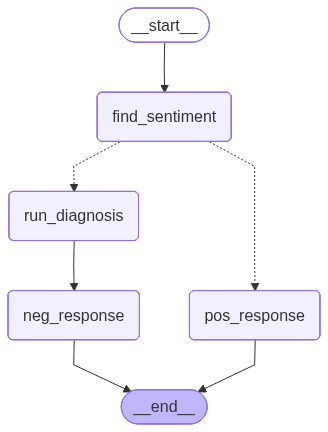

In [70]:
workflow

In [71]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': "Dear [User],\n\nI'm so sorry to hear that you're experiencing a bug issue with our system. I can imagine how frustrating that must be for you. I'm here to help, and I'll do my best to resolve the problem for you as quickly as possible.\n\nI've taken a look at your issue and I'm working on a resolution for you right now. In the meantime, I want to assure you that I'll do everything I can to minimize the impact this is having on your work.\n\nTo better understand the issue and provide a more effective solution, could you please provide more details about the bug you're experiencing? For example, what exactly is happening when the issue 